In [1]:
library(dplyr)
library(Seurat)
library(patchwork)
library(ggplot2)
library(RColorBrewer)
library(tibble)
library(clusterProfiler)
library(pheatmap)
library(philentropy)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t




clusterProfiler v4.14.4 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang,
W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize
multiomics data. Nature Protocols. 2024, 19(11):3292-3320


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter




ERROR: Error in library(philentropy): there is no package called ‘philentropy’


In [2]:
zemin <- readRDS("../B1_objects/zemin_lung.rds")

In [3]:
zemin_short <- subset(
  x = zemin,
  subset = Final_annotation %in% c("MF-Monocytes", "tumor", "fibroblast", "endothelial")
)


In [4]:
zemin_short <- NormalizeData(zemin_short)
zemin_short <- FindVariableFeatures(zemin_short)
zemin_short <- ScaleData(zemin_short)
zemin_short <- RunPCA(zemin_short)
zemin_short <- FindNeighbors(zemin_short, dims = 1:30, reduction = "pca")
zemin_short <- FindClusters(zemin_short, resolution = 0.3)
zemin_short <- RunUMAP(zemin_short, dims = 1:30, reduction = "pca", reduction.name = "umap")

Warning message:
“The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Centering and scaling data matrix

PC_ 1 
Positive:  DCN, CALD1, LUM, MGP, MFAP4, SPARCL1, THY1, RARRES2, FBLN1, COL1A1 
	   SERPINF1, TIMP3, TAGLN, LHFP, NNMT, CRISPLD2, TPM2, CTSK, PDGFRB, CCDC80 
	   PRELP, A2M, CD248, ACTA2, FN1, FSTL1, SOD3, OLFML3, SFRP2, PDLIM3 
Negative:  RSPH1, SNTN, C20orf85, C9orf24, FAM183A, TMEM190, MS4A8, FAM92B, LDLRAD1, CAPSL 
	   C1orf194, CAPS, ZMYND10, ROPN1L, C11orf88, PIFO, MORN5, CCDC78, C5orf49,

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12160
Number of edges: 433804

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9535
Number of communities: 17
Elapsed time: 1 seconds


Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
18:42:56 UMAP embedding parameters a = 0.9922 b = 1.112

18:42:56 Read 12160 rows and found 30 numeric columns

18:42:56 Using Annoy for neighbor search, n_neighbors = 30

18:42:56 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:42:58 Writing NN index file to temp file /tmp/RtmpAcmArj/fileb11931a08e43b

18:42:58 Searching Annoy index using 1 thread, search_k = 3000

18:43:02 Annoy recall = 100%

18:43:03 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors

Loading required package: viridisLite

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


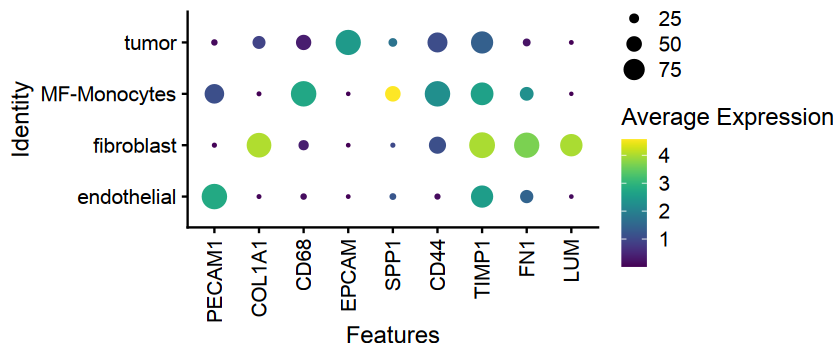

In [5]:
options(repr.plot.width = 7, repr.plot.height = 3)
library(RColorBrewer)
library(viridis)  # Matplotlib-style colormaps in R

DotPlot(
  zemin_short,
  features = c('PECAM1','COL1A1','CD68','EPCAM',
               'SPP1','CD44','TIMP1','FN1','LUM'),
  group.by = 'Final_annotation',
  scale = FALSE
) +
  scale_colour_viridis(option = "viridis") +   # "viridis","plasma","inferno","cividis","turbo", etc.
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))


In [6]:
# Create a general cell type annotation column

In [7]:
all <- readRDS("/storage/riosugimuralab/alexto/A2_AssemFlex/Flex.rds")

In [8]:
all.monoMac <- subset(
  all,
  cells = rownames(all@meta.data)[grepl("Mac", all@meta.data$cell_type)]
)


In [9]:
all.monoMac <- NormalizeData(all.monoMac)
all.monoMac <- FindVariableFeatures(all.monoMac)
all.monoMac <- ScaleData(all.monoMac)
all.monoMac <- RunPCA(all.monoMac)
all.monoMac <- FindNeighbors(all.monoMac, dims = 1:50, reduction = "pca")
all.monoMac <- FindClusters(all.monoMac, resolution = 0.5)
all.monoMac <- RunUMAP(all.monoMac, dims = 1:50, reduction = "pca", reduction.name = "umap")

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“Different features in new layer data than already exists for scale.data”
PC_ 1 
Positive:  MKI67, CDK1, CENPM, TYMS, KIFC1, NCAPG, FOXM1, TOP2A, ANLN, RRM2 
	   BIRC5, TPX2, NUSAP1, KIF11, LMNB1, NDC80, PCLAF, SPC24, CEP55, ZWINT 
	   KIF2C, MYBL2, HJURP, SHCBP1, SPC25, TK1, CDKN2C, PRC1, CIT, GTSE1 
Negative:  C5AR1, SLC11A1, ABCA1, PLAUR, TYMP, APOE, CTSL, CXCL16, ANPEP, SPP1 
	   SRGN, TREM2, FTH1, FCGR2A, IL7R, GLUL, CD9, FPR1, CD82, ARRDC3 
	   FCGR3A, ABCG1, C15orf48, SOCS3, MMP19, SOD2, MERTK, SLC2A3, ADAMTSL4, SLC16A10 
PC_ 2 
Positive:  EMP1, PLAUR, GLIPR2, SPP1, CD9, ANPEP, FGR, HSD3B7, BCL2A1, AQP9 
	   TGM2, SPOCD1, PHLDA1, IFI30, ATF3, CD52, SPINT1, OLR1, TM4SF19, FABP5 
	   SH3BGRL3, MMP19, KIFC3, MATK, RGCC, SLAMF7, LPL, DCSTAMP, ALDH1A2, HAPLN4 
Negative:  F13A1, GATM, SELENOP, FOLR2, IGFBP4, FSCN1, IGF1, FUCA1, GAS6, LGMN 
	   LILRB5, LPCAT1, CD20

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 19565
Number of edges: 691379

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8528
Number of communities: 10
Elapsed time: 3 seconds


18:44:24 UMAP embedding parameters a = 0.9922 b = 1.112

18:44:24 Read 19565 rows and found 50 numeric columns

18:44:24 Using Annoy for neighbor search, n_neighbors = 30

18:44:24 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:44:27 Writing NN index file to temp file /tmp/RtmpAcmArj/fileb1193169b487b

18:44:27 Searching Annoy index using 1 thread, search_k = 3000

18:44:33 Annoy recall = 100%

18:44:34 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:44:36 Initializing from normalized Laplacian + noise (using RSpectra)

18:44:37 Commencing optimization for 200 epochs, with 884164 positive edges

18:44:37 Using rng type: pcg

18:44:49 Optimization finished



In [10]:
zemin_alk <- subset(zemin_short, subset = driver_gene == "ALK")

In [11]:
# Analyze macrophage populations

In [12]:
assembloid.monomac <- subset(all.monoMac, subset = orig.ident == 'Assembloid')

In [13]:
ALK.MonoMac <- subset(zemin_alk, subset = Final_annotation == 'MF-Monocytes')

In [14]:
ALK.MonoMac$orig.ident <- 'Maynard 2020'

In [15]:
# Example sketch (details depend on how your assays/layers are set up)
flexzemin <- merge(assembloid.monomac, ALK.MonoMac)

flexzemin <- SCTransform(flexzemin, vst.flavor = "v2", verbose = FALSE)
flexzemin <- RunPCA(flexzemin, npcs = 30, verbose = FALSE)

flexzemin <- IntegrateLayers(
  object        = flexzemin,
  method        = HarmonyIntegration,   # or CCAIntegration, etc.
  orig.reduction = "pca",
  new.reduction  = "harmony",
  assay          = "SCT",
  verbose        = FALSE
)

flexzemin <- FindNeighbors(flexzemin, reduction = "harmony", dims = 1:30)
flexzemin <- FindClusters(flexzemin, resolution = 0.2)
flexzemin <- RunUMAP(flexzemin, reduction = "harmony", dims = 1:30)


The `features` argument is ignored by `HarmonyIntegration`.
This message is displayed once per session.
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 7823
Number of edges: 326077

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8928
Number of communities: 7
Elapsed time: 0 seconds


18:46:30 UMAP embedding parameters a = 0.9922 b = 1.112

18:46:30 Read 7823 rows and found 30 numeric columns

18:46:30 Using Annoy for neighbor search, n_neighbors = 30

18:46:30 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:46:31 Writing NN index file to temp file /tmp/RtmpAcmArj/fileb11937ea843c1

18:46:31 Searching Annoy index using 1 thread, search_k = 3000

18:46:34 Annoy recall = 100%

18:46:35 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:46:37 Initializing from normalized Laplacian + noise (using RSpectra)

18:46:37 Commencing optimization for 500 epochs, with 335656 positive edges

18:46:37 Using rng type: pcg

18:46:50 Optimization finished



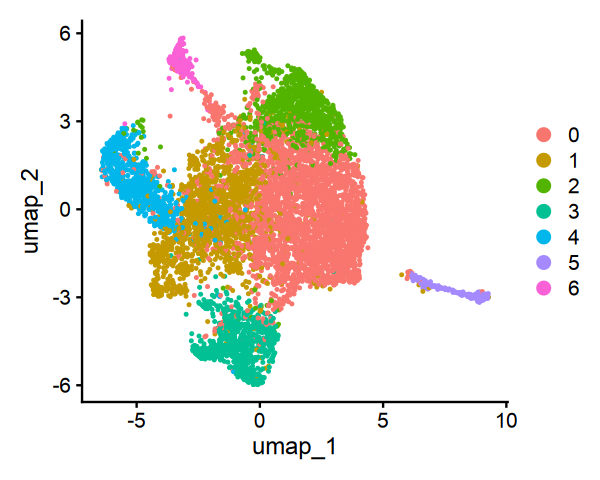

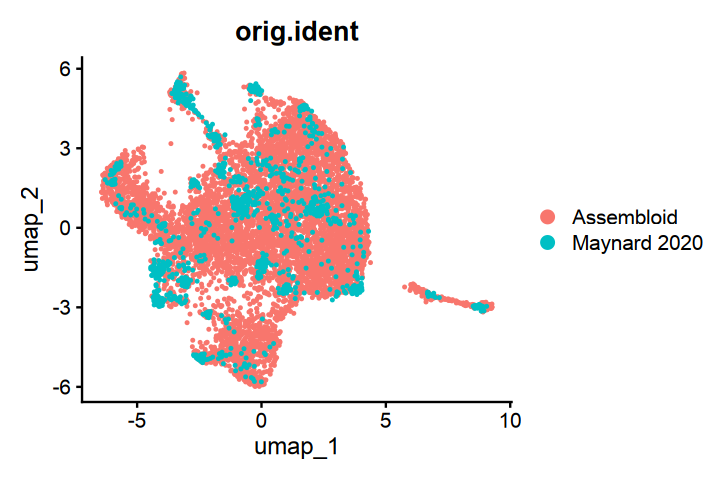

In [16]:
options(repr.plot.width = 5, repr.plot.height = 4)
DimPlot(flexzemin)
options(repr.plot.width = 6, repr.plot.height = 4)
DimPlot(flexzemin, group.by='orig.ident')

In [17]:
# Extract metadata from the flexzemin object
# Use Prism 10 to visualize the cell type distribution


meta <- flexzemin@meta.data
tab <- table(meta$seurat_clusters, meta$orig.ident)
tab_pct <- prop.table(tab, margin = 2) * 100
df_wide <- as.data.frame.matrix(tab_pct)
df_wide$seurat_clusters <- rownames(df_wide)

# Organize columns with your specific identities: "Assembloid" and "Maynard 2020"
cluster_by_origident_df <- df_wide[, c("seurat_clusters", "Assembloid", "Maynard 2020")]
cluster_by_origident_df

,seurat_clusters,Assembloid,Maynard 2020
,<chr>,<dbl>,<dbl>
0,0,41.589844,34.494196
1,1,19.978842,33.996683
2,2,13.873357,9.701493
3,3,10.473024,7.048093
4,4,9.717395,6.135987
5,5,2.674928,2.653400
6,6,1.692610,5.970149
